In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json, random, pickle
from collections import Counter
from pathlib import Path
from pydicom import dcmread

I0000 00:00:1782250252.586008  899510 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [3]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [4]:
# Get the headers
pkl = Path("/home/anya.tongprasith001/U54REC/release_to_header_mapping.pkl")
mapping = pickle.load(open(pkl, "rb"))
len(mapping)

163568

In [5]:
# Get the images, labels, and headers
noncancer = {}
cancer = {}

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["label"] == "Unknown" :
        continue
        
    # Load image
    img = np.load(ID)['data']
    img = img.astype("float32") / 255.0 # Normalize to 0-1
    img = np.expand_dims(img, axis=-1)
    # Load headers
    ds = mapping[Path(ID).stem]
    bdthickness = ds.BodyPartThickness
    age_str = ds.PatientAge
    if age_str and age_str != '':
        age = float(age_str[:-1]) / 12.0
    else:
        age = -1.0 
            
    if meta["label"] == "NonCancer" :
        if meta["PatientID"] not in noncancer.keys() :
            noncancer[meta["PatientID"]] = []
        noncancer[meta["PatientID"]].append([img, [bdthickness, age], 0])

    else : 
        if meta["PatientID"] not in cancer.keys() :
            cancer[meta["PatientID"]] = []
        cancer[meta["PatientID"]].append([img, [bdthickness, age], 1])

In [6]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

I0000 00:00:1782250622.420829  899510 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0


In [7]:
print(len(noncancer.keys()))
print(len(cancer.keys()))

154238
3562


In [8]:
# Create balance non-cancer ds
noncancer_ls = list(noncancer.items())
nc = noncancer_ls[:len(cancer.keys())]

cancer_ls = list(cancer.items())
c = cancer_ls

print(len(nc), len(c))

3562 3562


In [9]:
# Split patients and shuffle them
train_size = int(0.7 * len(nc)) 
val_size = int(0.15 * len(nc))
test_size = int(0.15 * len(nc))

train_ncp, train_cp = nc[:train_size], c[:train_size]
val_ncp, val_cp = nc[train_size:val_size + train_size], c[train_size:val_size + train_size]
test_ncp, test_cp = nc[val_size + train_size:val_size + train_size + test_size], c[val_size + train_size:val_size + train_size + test_size]

print(f"Noncancer Train: {len(train_ncp)}, Val: {len(val_ncp)}, Test: {len(test_ncp)}")
print(f"Cancer Train: {len(train_ncp)}, Val: {len(val_ncp)}, Test: {len(test_ncp)}")

train_ds = train_ncp + train_cp
val_ds = val_ncp + val_cp
test_ds = test_ncp + test_cp
random.shuffle(train_ds)
random.shuffle(val_ds)
random.shuffle(test_ds)

Noncancer Train: 2493, Val: 534, Test: 534
Cancer Train: 2493, Val: 534, Test: 534


In [10]:
# Assign the images, metadata, and labels for setting up mix input
def assign_data(dataset) :
    images, metadata, labels = [],[],[]
    for patient, data_list in dataset :
        for data in data_list :
            images.append(data[0])
            metadata.append(data[1])
            labels.append(data[2])
    return images, metadata, labels

train_imgs, train_metadata, train_labels = assign_data(train_ds)
val_imgs, val_metadata, val_labels = assign_data(val_ds)
test_imgs, test_metadata, test_labels = assign_data(test_ds)

train_imgs = np.array(train_imgs, dtype=np.float32)
train_metadata = np.array(train_metadata, dtype=np.float32)
train_labels = np.array(train_labels, dtype=np.float32)
val_imgs = np.array(val_imgs, dtype=np.float32)
val_metadata = np.array(val_metadata, dtype=np.float32)
val_labels = np.array(val_labels, dtype=np.float32)
test_imgs = np.array(test_imgs, dtype=np.float32)
test_metadata = np.array(test_metadata, dtype=np.float32)
test_labels = np.array(test_labels, dtype=np.float32)

In [11]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.6839
Average class probability in validation set: 0.6620
Average class probability in test set:       0.6304


In [12]:
# Check dimension size and color channel
print("Shape:", train_imgs[0].shape)

Shape: (256, 256, 1)


In [13]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices(({'image_input': train_imgs, 'meta_input': train_metadata}, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices(({'image_input': val_imgs, 'meta_input': val_metadata}, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices(({'image_input': test_imgs, 'meta_input': test_metadata}, test_labels))
test_ds = test_ds.batch(32)

In [14]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [20]:
# Create convolutional base
model = models.Sequential()
model.add(layers.Input(shape=(256, 256, 1))),
model.add(layers.Conv2D(32, 3, activation='relu')),
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(256, 256, 1), name = 'image_input')
x = data_augmentation(image_input)

# Keep base model in inference mode
x = model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

# Metadata branch
meta_input = tf.keras.Input(shape=(2,), name='meta_input')  # 2 headers
m = layers.Dense(16, activation='relu')(meta_input) 

combined = layers.Concatenate()([x, m])
outputs = layers.Dense(1, activation="sigmoid")(combined)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = [image_input, meta_input], outputs = outputs) # wrap all layers

In [23]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [24]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [25]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20


I0000 00:00:1782251816.688467  904715 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - auc: 0.5408 - loss: 0.6486 - val_auc: 0.6229 - val_loss: 0.6315
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - auc: 0.5934 - loss: 0.6108 - val_auc: 0.6487 - val_loss: 0.6202
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - auc: 0.6048 - loss: 0.6044 - val_auc: 0.6606 - val_loss: 0.6148
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - auc: 0.6079 - loss: 0.6027 - val_auc: 0.6640 - val_loss: 0.6120
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - auc: 0.6085 - loss: 0.6023 - val_auc: 0.6676 - val_loss: 0.6120
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - auc: 0.6110 - loss: 0.6016 - val_auc: 0.6675 - val_loss: 0.6103
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - auc: 0.6146 - loss: 0.6008 - val_auc: 0.6689 - val_loss: 0.6093
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc: 0.6143 - loss: 0.6004 - val_auc: 0.6690 - val_loss: 0.6083
Epoch 9/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - auc

In [26]:
# Evaluate model
model.evaluate(test_ds)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.6252 - loss: 0.6479


[0.6478962302207947, 0.6251752972602844]

In [27]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


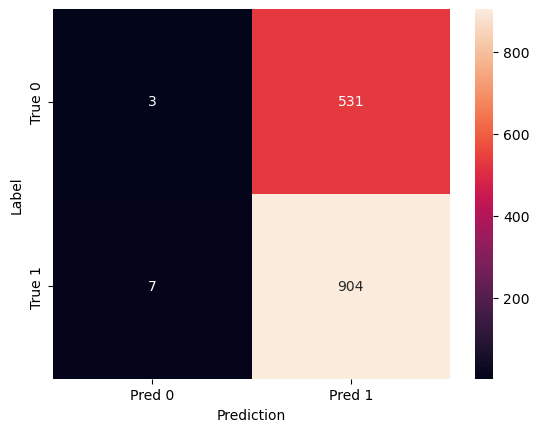

In [28]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

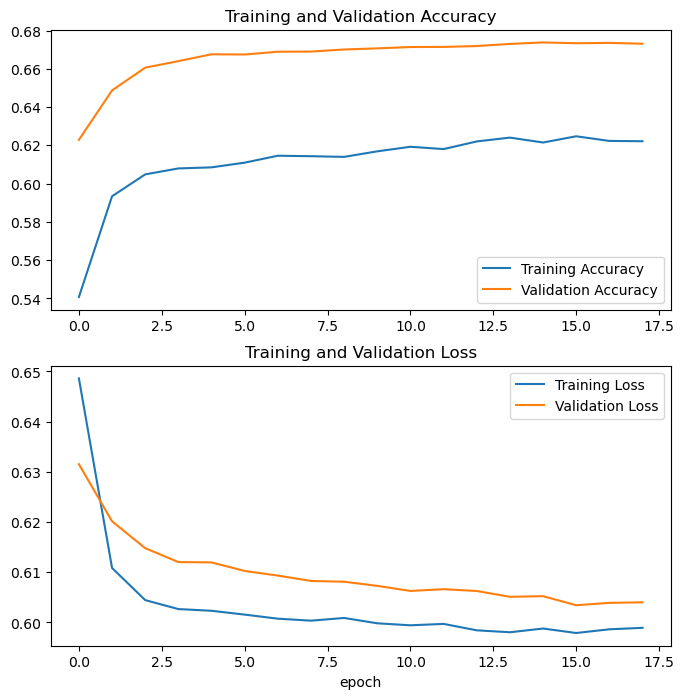

In [29]:
# Combine both for plotting
acc = history.history['auc']
val_acc = history.history['val_auc']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()